# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Date_Analysis/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

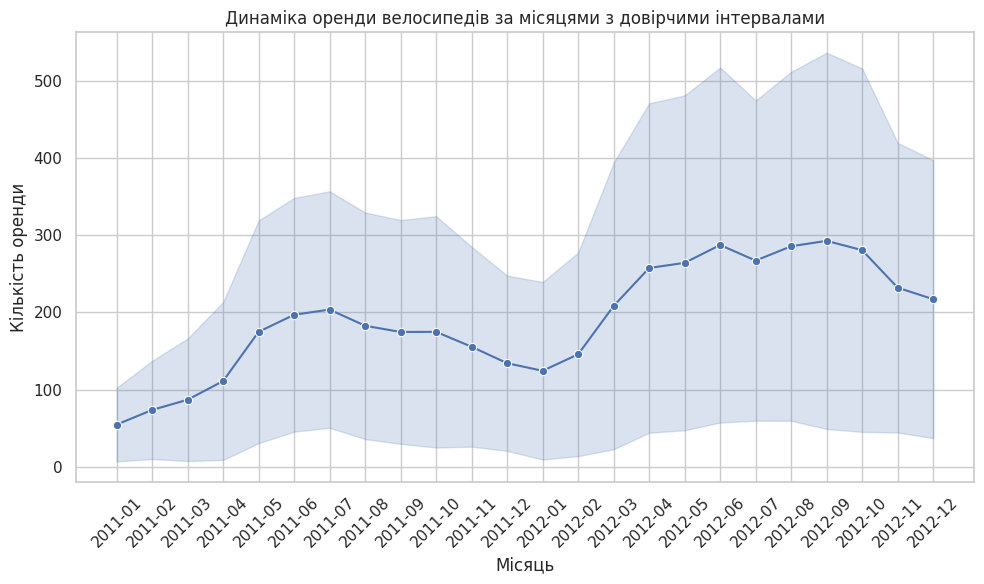

In [4]:
plt.figure(figsize=(10,6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

Найбільше відхилення від середнього можна спостерігати в червні та у вересні 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

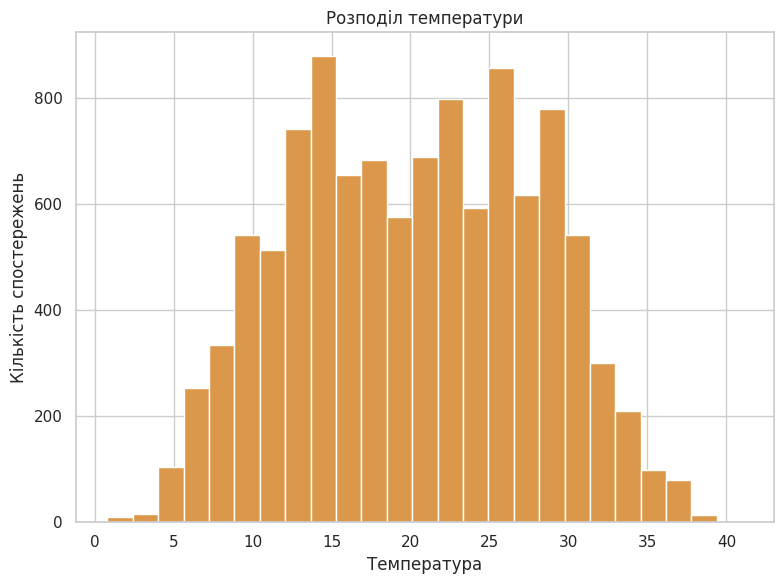

In [5]:
# Pandas
df.temp.plot.hist(
    bins=25,
    figsize=(8, 6),
    xlabel='Температура',
    ylabel='Кількість спостережень',
    title='Розподіл температури',
    color='#db984b')
plt.tight_layout();

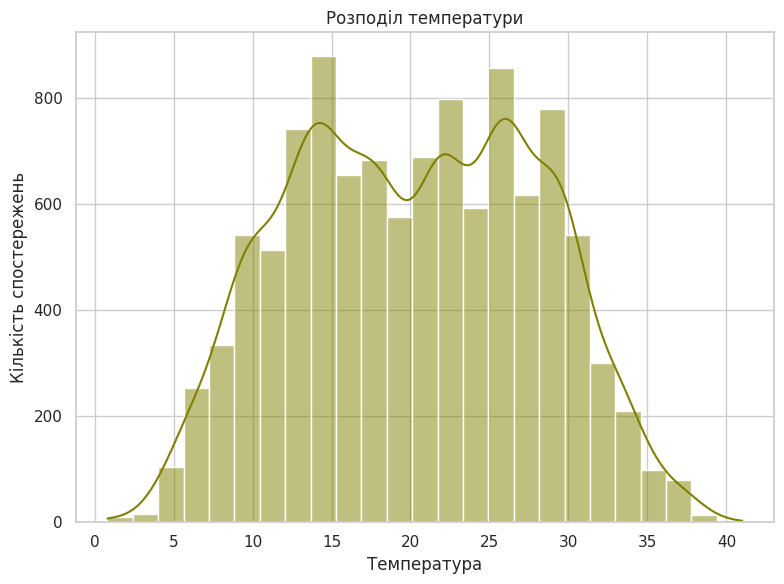

In [6]:
# Seaborn
plt.figure(figsize=(8,6))
sns.histplot(
    data=df.temp,
    bins=25,
    kde=True,
    color='olive')
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Кількість спостережень')
plt.tight_layout();

1. Гістрограма створена за допомогою бібліотеки Seaborn відрізняється від гістограми Pandas тим, що додатково має згладжену криву розподілу даних та її біни напівпрозорі.
2. Kernel Density Estimate (оцінка щільності ймовірності)- це крива, яка згладжує стовпці гістограми.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

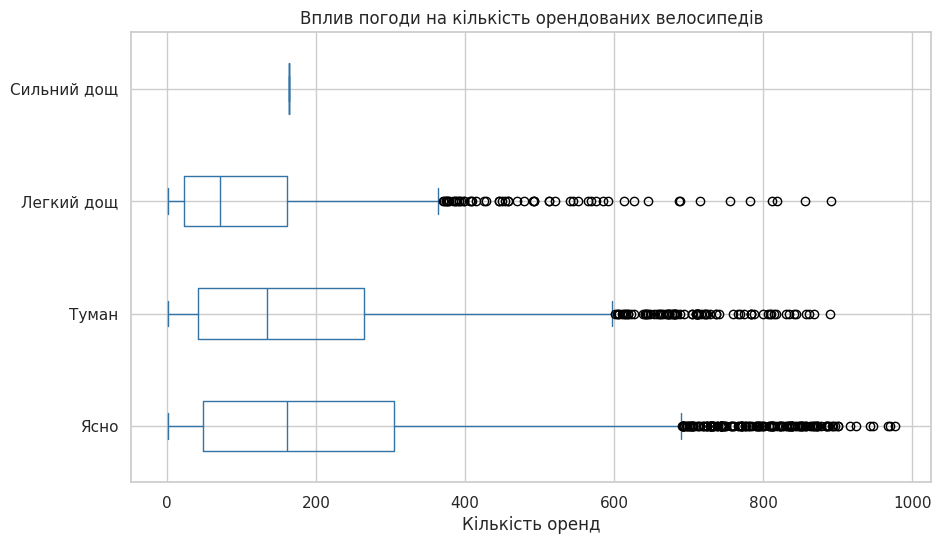

In [7]:
# Pandas
ax = df.boxplot(
    column='count',
    by='weather',
    figsize=(10,6),
    vert=False,
    color='#3273a8')

plt.title('Вплив погоди на кількість орендованих велосипедів')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('')

plt.yticks(
    [1,2,3,4],
    ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
);

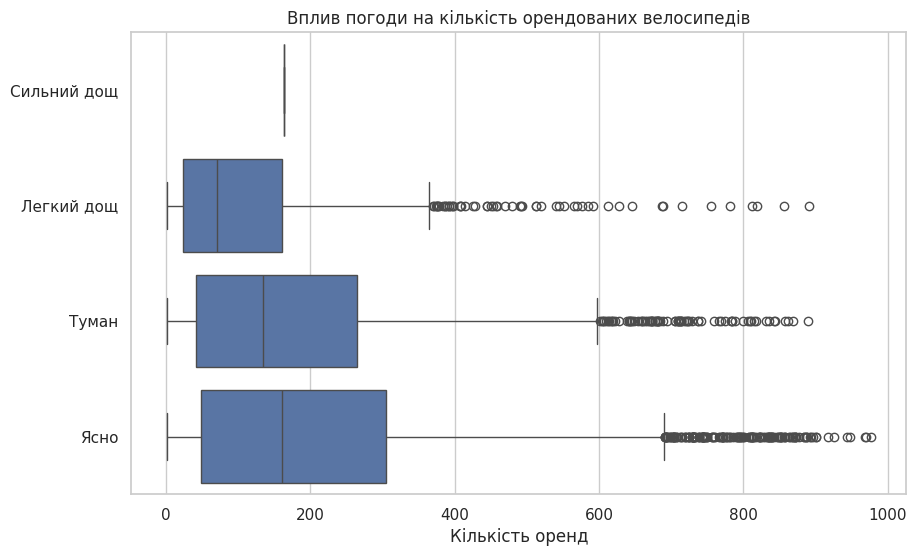

In [8]:
# Seaborn
df['weather'] = pd.Categorical(df['weather'])

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='count',
    y='weather')

plt.gca().invert_yaxis()

plt.title('Вплив погоди на кількість орендованих велосипедів')
plt.xlabel('Кількість оренд')
plt.ylabel('')
plt.yticks(
    [0,1,2,3],
    ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']);

У Pandas, бокс-плот побудувався чорно-білим за замовченням, що вже виглядає не дуже естетично, також бокси не зафарбовані і їх розміри менші, на відміну від боксів у Seaborn.

У Seaborn, для того, щоб зробити візуалізацію горизонтальною довелось зробити колонку 'weather' категоріальною.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [9]:
cor_matrix = df[['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
                 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

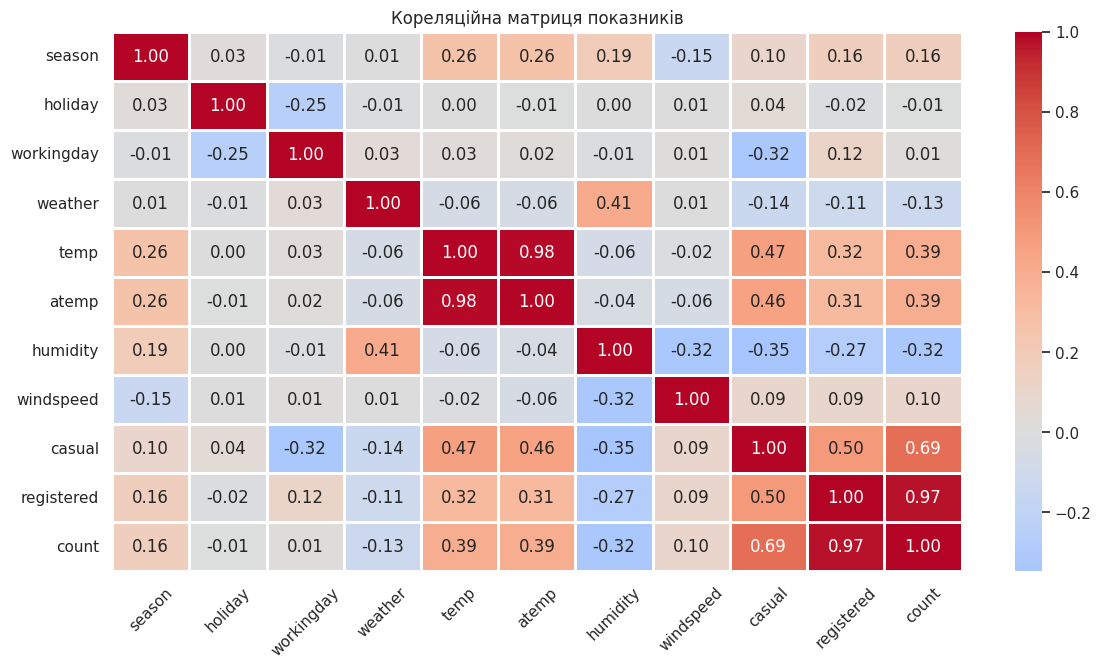

In [10]:
plt.figure(figsize=(12,7))

sns.heatmap(cor_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            linewidths=1,
            fmt='.2f')

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.xticks(rotation=45);

1. Змінні *casual* та *registered*, що логічно, так як у сумі ці два числа дорівнюють значенню *count*. Крім цього, показники *temp* та *atemp* найсильніше корелюють з числом оренди count. Що є досить логічним, коли температура повітря зростає, кількість оренди, також, зростає.
2. Кореляція між t*emp* та *atemp* дуже висока - *0.98*. Це свідчить про те, що між змінними майже ідеальний взяємозв'язок. Коли *temp* зростає, *atemp* також зростає, і навпаки.
3. Наступні змінні мають негативну кореляцію (>=0.25):
- holiday та workingday: -0.25.
- workingday та casual: -0.32.
- humidity та windspeed: -0.32.
- humidity та casual: -0.35.
- humidity та registered: -0.27.
- humidity та count: -0.32.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


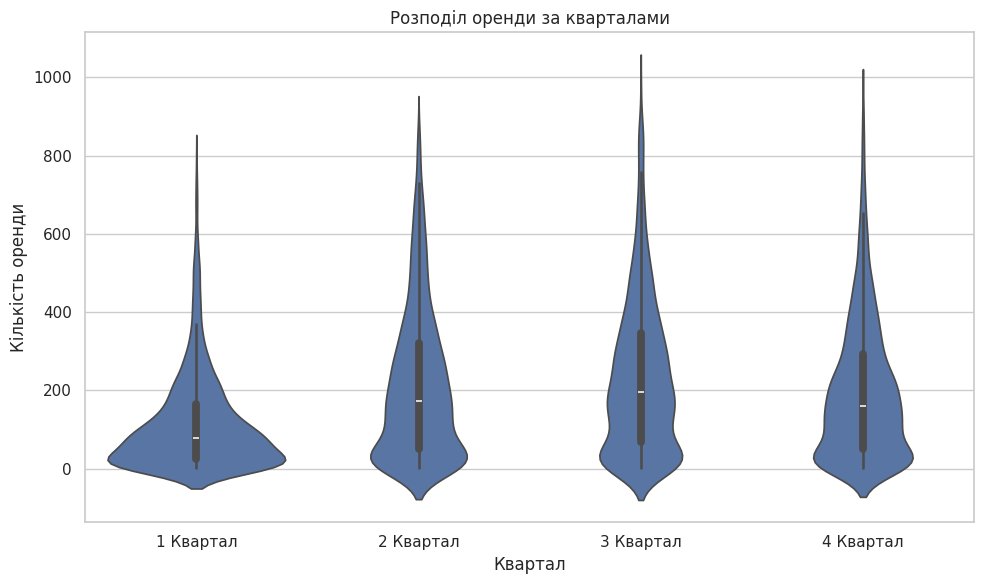

In [11]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df,
               x='season',
               y='count')
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренди')
plt.tight_layout()
plt.xticks([0, 1, 2, 3],
    ['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал'])
plt.show()

1. Показує, де зосереджено найбільше значень у розподілі. Чим ширше місце, тим більше значень з такою кількістю оренд.
2. У 3му кварталі спостерігається найбільша варіабельність оренди.
3. У violin plot, окрім box plot, на візуалізації, також,  можна побачити розподіл данних по категоріям.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [12]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count','season']].sample(frac=0.05)

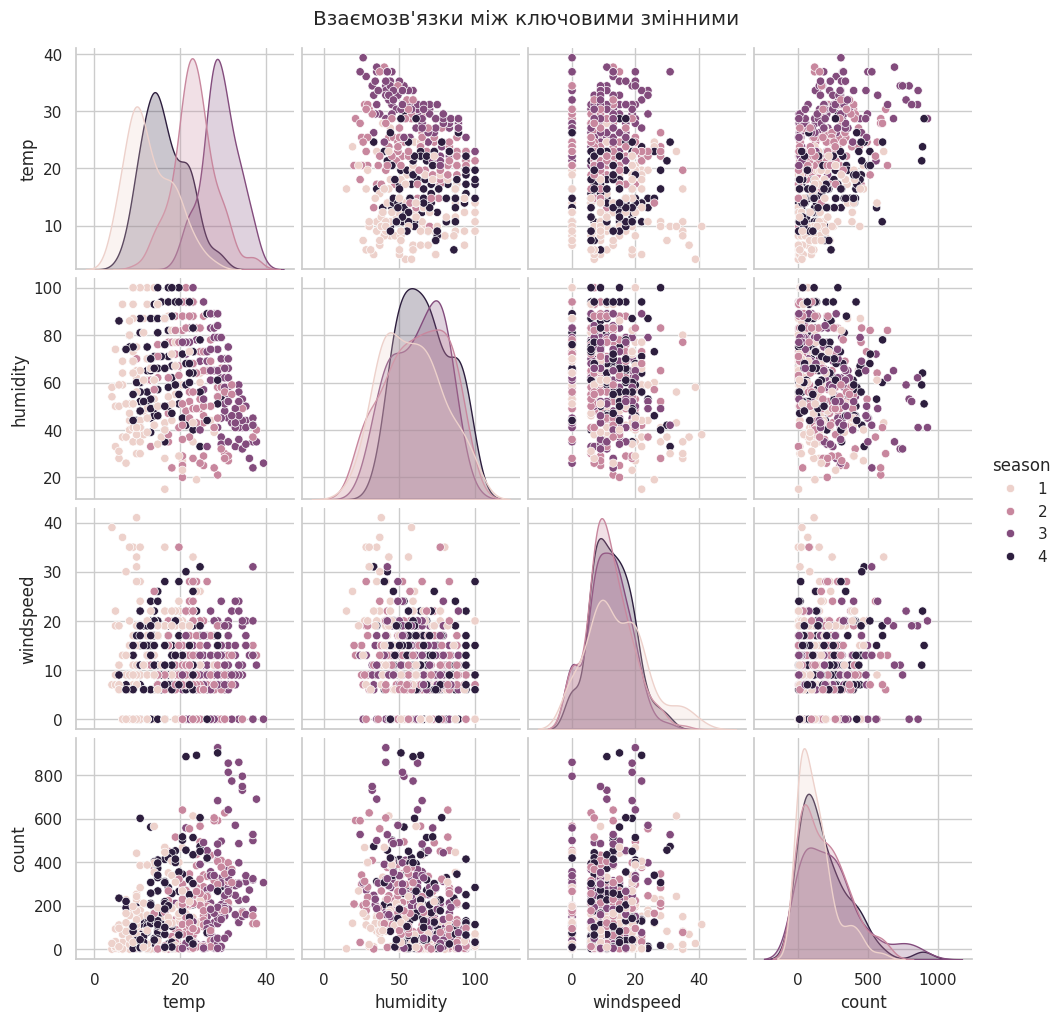

In [13]:
sns.pairplot(sample_df, hue='season')
plt.suptitle('Взаємозв\'язки між ключовими змінними', y=1.02)
plt.show()

1. Між змінними *temp* і *count* спостерігається найсильніший лінійний зв'язок. Температура росте і кількість оренд збільшується, ця закономірність зберігається протягом усіх 4х сезонів.
2. Температура (temp) найбільше різниться між кварталами, що є доволі логічним - температура змінюється в залежності від пори року.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

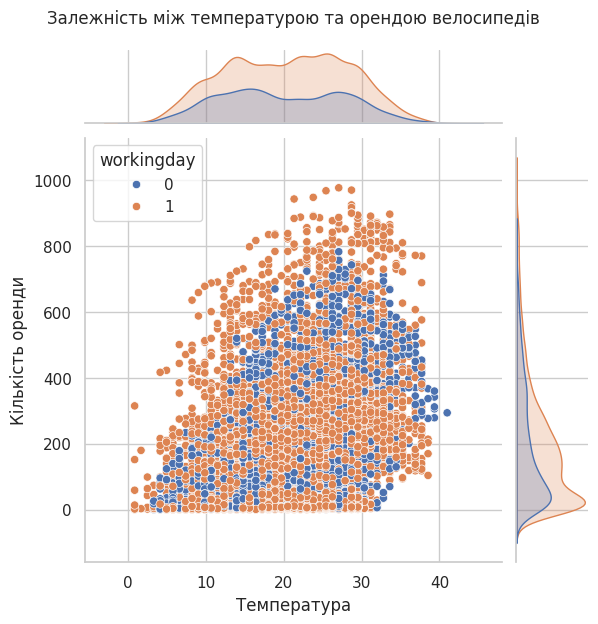

In [14]:
sns.jointplot(data=df,
              x='temp',
              y='count',
              hue='workingday')
plt.title('Залежність між температурою та орендою велосипедів', y=1.25)
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')
plt.show()

1. Верхній графік показує розподіл температури, тобто при якій температурі дані спостерігаються частіше. Графік справа - це розподіл кількості орендованих велосипедів, тобто, яка кількість велосипедів орендують частіше.
2. На скатер плоті добре видно, що у робочі дні кількість спостережень більша та частіше досягає вищих значень.